# Multi-Community QIGNN with Orthogonality Regularization

Расширение `community_detection_multi_k.ipynb`. В предыдущем эксперименте
выяснилось, что multi-community формулировка ($k>2$) часто **тривиально
коллапсирует** — GNN сваливает все вершины в одно сообщество (constraint
удовлетворён, modularity=0, локальный минимум). Из 5 shots обычно только 1–2
находили нетривиальное разбиение.

**Идея регуляризации (по аналогии с DMoN, Tsitsulin et al. 2020):**
добавляем к лоссу штраф за неортогональность колонок матрицы $P\in\mathbb R^{n\times k}$
(распределения soft-assignment по сообществам):

$$
\mathcal L_{\text{ortho}} =
\Bigl\|\frac{P^\top P}{\|P^\top P\|_F} - \frac{I_k}{\sqrt{k}}\Bigr\|_F^2.
$$

Ноль достигается, когда $P^\top P$ пропорциональна единичной матрице — т.е.
колонки попарно ортогональны (сообщества не перекрываются и
сбалансированы по размеру). Тривиальный коллапс ($P$ имеет одну "горячую"
колонку, все остальные — нули) даёт $\mathcal L_{\text{ortho}} = (1-1/\sqrt k)^2 + (k-1)/k$
(аналитически проверено в smoke-тесте), что максимум.

Полный лосс:
$$
\mathcal L_{\text{total}} = p^\top Q\, p
+ \lambda(t)\sum_i |p_i(1-p_i)|
+ \alpha\,\mathcal L_{\text{ortho}}.
$$

**Эксперимент.** Karate, $k\in\{3,4,5,6\}$, $\alpha\in\{0, 0.1, 1.0, 10.0\}$
(где $\alpha=0$ — baseline без ortho), по 10 shots на каждую комбинацию.
Метрики: модулярность, NMI, доля shots с trivial collapse (largest community
$\geq 80\%$), число реально использованных сообществ, runtime.

In [1]:
import dgl
import torch
import random
import os
import sys
import numpy as np
import pandas as pd
import networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from collections import OrderedDict, defaultdict
from dgl.nn.pytorch import SAGEConv
from itertools import chain
from time import time

from sklearn.metrics import normalized_mutual_info_score

sys.path.insert(0, os.getcwd())
from qubo_modularity import gen_q_dict_modularity_multi

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

FIG_DIR = os.path.join(os.getcwd(), 'figures')
RES_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

%matplotlib inline

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TORCH_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.float32
print(f'Device: {TORCH_DEVICE}, dtype: {TORCH_DTYPE}')

# ---------------- Architecture (copied from community_detection_multi_k.ipynb) ----------------
class SAGEResBlockMulti(torch.nn.Module):
    def __init__(self, in_channels, out_channels, feat_drop=0.):
        super().__init__()
        self.sage1 = SAGEConv(in_channels, out_channels, aggregator_type='mean',
                              feat_drop=feat_drop, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.sage2 = SAGEConv(in_channels, out_channels, aggregator_type='pool',
                              feat_drop=feat_drop, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self, graph, x, edge_weight=None):
        out1 = self.bn1(self.sage1(graph, x, edge_weight))
        out2 = self.bn2(self.sage2(graph, x, edge_weight))
        return self.relu(out1 + out2)


class ResSAGEMulti(torch.nn.Module):
    def __init__(self, in_feats, hidden_sizes, number_classes, dropout, device):
        super().__init__()
        self.dropout_frac = dropout
        self.number_classes = number_classes
        self.layers = nn.ModuleList()
        cur = in_feats
        if isinstance(hidden_sizes, int):
            hidden_sizes = [hidden_sizes]
        for hd in hidden_sizes:
            self.layers.append(SAGEResBlockMulti(cur, hd).to(device))
            self.layers.append(torch.nn.LeakyReLU())
            cur = hd
        self.layers.append(SAGEConv(cur, number_classes, aggregator_type='mean').to(device))

    def forward(self, graph, h, h0, edge_weight=None):
        h = torch.cat([h, h0], 1)
        for layer, norm in zip(self.layers[:-1][::2], self.layers[:-1][1::2]):
            h = layer(graph, h, edge_weight)
            h = norm(h)
        h = F.dropout(h, p=self.dropout_frac)
        h0_new = self.layers[-1](graph, h, edge_weight)
        return F.softmax(h0_new, dim=1), h0_new


def get_gnn_multi(n_nodes, gnn_hypers, opt_params, torch_device, torch_dtype):
    de = gnn_hypers['dim_embedding']; hd = gnn_hypers['hidden_dim']
    dr = gnn_hypers['dropout'];       k  = gnn_hypers['number_classes']
    in_feats = de + 1 * k + 4 * de
    net = ResSAGEMulti(in_feats, hd, k, dr, torch_device).type(torch_dtype).to(torch_device)
    embed = nn.Embedding(n_nodes, de).type(torch_dtype).to(torch_device)
    optimizer = torch.optim.Adam(chain(net.parameters(), embed.parameters()), **opt_params)
    return net, embed, optimizer


def pagerank_features(nx_graph, feature_dim=10):
    feats = torch.zeros((nx_graph.number_of_nodes(), feature_dim))
    pr = nx.pagerank(nx.Graph(nx_graph))
    for v, val in pr.items():
        feats[v, :] = val
    return feats


def _modularity_edge_weights(nx_G, dgl_graph, dtype, device):
    nodes = list(nx_G.nodes())
    A = nx.to_numpy_array(nx_G, nodelist=nodes, weight=None)
    deg = A.sum(axis=1)
    m = nx_G.number_of_edges()
    B = A - np.outer(deg, deg) / (2.0 * m)
    B_t = torch.tensor(-B, dtype=dtype, device=device)
    src, dst = dgl_graph.edges()
    return B_t[src, dst]

Device: cpu, dtype: torch.float32


# Step 1 — Загрузка графа Karate

In [3]:
graph = nx.karate_club_graph()
nodes = list(graph.nodes())
n_nodes = len(nodes)
print(f'Karate: n={n_nodes}, m={graph.number_of_edges()}')

club_to_label = {'Mr. Hi': 0, 'Officer': 1}
true_labels = np.array([club_to_label[graph.nodes[v]['club']] for v in nodes])
graph_dgl = dgl.from_networkx(graph).to(TORCH_DEVICE)

# Compute B once and the matched penalty P that worked in the previous notebook.
A = nx.to_numpy_array(graph, nodelist=nodes, weight=None)
deg = A.sum(axis=1)
m_edges = graph.number_of_edges()
B = A - np.outer(deg, deg) / (2.0 * m_edges)
P_PENALTY = 1.5 * float(np.max(np.abs(B)))
print(f'Constraint penalty P = 1.5 * max|B| = {P_PENALTY:.4f}')

# Louvain reference for plots.
t0 = time()
louv_comms = nx.community.louvain_communities(graph, seed=SEED)
louv_time = time() - t0
louv_mod = float(nx.community.modularity(graph, louv_comms))
node_to_comm = {v: c for c, comm in enumerate(louv_comms) for v in comm}
louv_pred = np.array([node_to_comm[v] for v in nodes])
louv_nmi = float(normalized_mutual_info_score(true_labels, louv_pred))
print(f'Louvain (auto k={len(louv_comms)}): mod={louv_mod:.4f}, NMI={louv_nmi:.4f}')

Karate: n=34, m=78
Constraint penalty P = 1.5 * max|B| = 2.7788
Louvain (auto k=4): mod=0.4266, NMI=0.5942


# Step 2 — Loss + training с ortho-регуляризацией; baseline vs ortho

In [4]:
def loss_func_multi_v2(P, Q_mat, epoch=0, alpha_ortho=0.0, n=None, k=None):
    """Multi-class QUBO loss with optional orthogonality regularizer.

    Returns (total_loss, components_dict) where components_dict has keys
    'qubo', 'annealing', 'ortho' (each a Python float, no autograd graph).
    """
    p_flat = P.reshape(-1)
    qubo_loss = p_flat @ Q_mat @ p_flat
    lbd = epoch / 1e4
    annealing = lbd * (p_flat * (1 - p_flat)).abs().sum()

    if alpha_ortho > 0:
        if k is None:
            k = P.shape[1]
        PtP = P.T @ P
        PtP_n = PtP / (torch.norm(PtP, p='fro') + 1e-10)
        I_n = torch.eye(k, device=P.device, dtype=P.dtype) / np.sqrt(k)
        ortho = torch.norm(PtP_n - I_n, p='fro') ** 2
    else:
        ortho = torch.tensor(0.0, device=P.device, dtype=P.dtype)

    total = qubo_loss + annealing + alpha_ortho * ortho
    return total, {
        'qubo': float(qubo_loss.detach()),
        'annealing': float(annealing.detach()),
        'ortho': float(ortho.detach()),
    }


def run_gnn_training_multi_v2(q_torch, dgl_graph, nx_G, k, net, embed, optimizer,
                              number_epochs, tol, patience, alpha_ortho=0.0,
                              log_every=500):
    """v2 training: same as run_gnn_training_multi, plus alpha_ortho and per-epoch
    component logging (`history` returned)."""
    n = dgl_graph.number_of_nodes()
    dtype = q_torch.dtype
    device = q_torch.device

    edge_weight = _modularity_edge_weights(nx_G, dgl_graph, dtype, device)

    inputs = torch.rand((n, 10), dtype=dtype, device=device)
    walk = pagerank_features(dgl_graph.cpu().to_networkx(), 2 * inputs.shape[1])
    inputs = torch.cat([inputs, torch.ones_like(inputs), torch.ones_like(inputs),
                        walk.to(device)], 1)

    h0 = torch.zeros(n, k, device=device, dtype=dtype)

    prev_loss = 1.0
    count = 0
    init_assn = torch.zeros(n, dtype=torch.long, device=device)
    X0 = torch.zeros(n, k, dtype=dtype, device=device); X0[:, 0] = 1.0
    best_proj_loss = loss_func_multi_v2(X0, q_torch, alpha_ortho=alpha_ortho, k=k)[0].detach()
    best_assignment = init_assn.clone()
    best_probs = X0.clone()
    best_epoch = 0

    history = []
    t0 = time()
    for epoch in range(number_epochs):
        probs, h0 = net(dgl_graph, inputs, h0.detach(), edge_weight)
        loss, comps = loss_func_multi_v2(probs, q_torch, epoch=epoch,
                                         alpha_ortho=alpha_ortho, n=n, k=k)
        loss_val = loss.detach().item()

        with torch.no_grad():
            assignment = probs.argmax(dim=1)
            X_proj = torch.zeros_like(probs)
            X_proj.scatter_(1, assignment.unsqueeze(1), 1.0)
            proj_loss = loss_func_multi_v2(X_proj, q_torch, alpha_ortho=alpha_ortho,
                                           k=k)[0].detach()
            if proj_loss < best_proj_loss:
                best_proj_loss = proj_loss
                best_assignment = assignment.detach().clone()
                best_probs = probs.detach().clone()
                best_epoch = epoch

        if epoch % log_every == 0:
            history.append({'epoch': epoch, **comps, 'total': loss_val,
                            'proj_loss': float(best_proj_loss)})

        if (abs(loss_val - prev_loss) <= tol) | ((loss_val - prev_loss) > 0):
            count += 1
        else:
            count = 0
        if count >= patience:
            break
        prev_loss = loss_val

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=2.0, norm_type=2)
        optimizer.step()

    elapsed = time() - t0
    return {
        'best_epoch': best_epoch,
        'best_assignment': best_assignment.detach().cpu().numpy().astype(int),
        'best_probs': best_probs.detach().cpu().numpy(),
        'best_proj_loss': float(best_proj_loss),
        'history': history,
        'time': elapsed,
    }


def assignment_to_communities(assignment, nodes):
    groups = defaultdict(set)
    for v, lbl in zip(nodes, assignment):
        groups[int(lbl)].add(v)
    return [frozenset(s) for s in groups.values() if len(s) > 0]


def is_collapse(assignment, threshold=0.8):
    """True if the largest community contains >= threshold of all nodes."""
    counts = np.bincount(assignment.astype(int))
    return counts.max() / len(assignment) >= threshold


def evaluate_assignment(nx_G, assignment, true_labels, nodes):
    communities = assignment_to_communities(assignment, nodes)
    if len(communities) <= 1:
        mod = 0.0
    else:
        mod = float(nx.community.modularity(nx_G, communities))
    nmi = float(normalized_mutual_info_score(true_labels, assignment))
    return {
        'modularity': mod,
        'nmi': nmi,
        'n_used': len(communities),
        'collapsed': bool(is_collapse(assignment)),
    }


# ----------------------- Experiment grid -----------------------
KS = [3, 4, 5, 6]
ALPHAS = [0.0, 0.1, 1.0, 10.0]   # 0.0 = baseline
N_SHOTS = 10
EPOCHS = 10000
TOL = 1e-4
PATIENCE = 1000

records = []        # one row per shot
component_traces = {}  # (k, alpha) -> list of histories per shot

for k in KS:
    Q_dict = gen_q_dict_modularity_multi(graph, k=k, P=P_PENALTY)
    N = n_nodes * k
    q_t = torch.zeros(N, N, dtype=TORCH_DTYPE, device=TORCH_DEVICE)
    for (i, j), v in Q_dict.items():
        q_t[i, j] = v
    print(f'\n############ k={k} (N={N}, nnz_Q={len(Q_dict)}) ############')

    for alpha in ALPHAS:
        print(f'  --- alpha_ortho = {alpha} ---')
        gnn_hypers = {'dim_embedding': 10, 'hidden_dim': 50,
                      'number_classes': k, 'dropout': 0.5}
        opt_params = {'lr': 0.014}
        traces_for_combo = []

        for shot in range(N_SHOTS):
            sd = SEED + shot
            random.seed(sd); np.random.seed(sd); torch.manual_seed(sd)
            net, embed, optimizer = get_gnn_multi(n_nodes, gnn_hypers, opt_params,
                                                  TORCH_DEVICE, TORCH_DTYPE)
            res = run_gnn_training_multi_v2(
                q_t, graph_dgl, graph, k, net, embed, optimizer,
                number_epochs=EPOCHS, tol=TOL, patience=PATIENCE,
                alpha_ortho=alpha
            )
            metrics = evaluate_assignment(graph, res['best_assignment'], true_labels, nodes)
            row = {
                'k': k, 'alpha': alpha, 'shot': shot, 'seed': sd,
                'modularity': metrics['modularity'], 'nmi': metrics['nmi'],
                'n_used': metrics['n_used'], 'collapsed': metrics['collapsed'],
                'best_epoch': res['best_epoch'], 'time': res['time'],
            }
            records.append(row)
            traces_for_combo.append(res['history'])
            mark = '!' if metrics['collapsed'] else ' '
            print(f'    shot {shot:>2}: mod={metrics["modularity"]:.4f}, '
                  f'NMI={metrics["nmi"]:.4f}, used={metrics["n_used"]}, '
                  f'collapse={mark}, t={res["time"]:.1f}s')
        component_traces[(k, alpha)] = traces_for_combo

df = pd.DataFrame(records)
csv_path = os.path.join(RES_DIR, 'ortho_experiment_raw.csv')
df.to_csv(csv_path, index=False)
print(f'\nWrote {csv_path} ({len(df)} rows)')
df.head()


############ k=3 (N=102, nnz_Q=1887) ############
  --- alpha_ortho = 0.0 ---


    shot  0: mod=0.0000, NMI=0.0000, used=1, collapse=!, t=2.7s


    shot  1: mod=0.1790, NMI=0.1216, used=2, collapse= , t=4.0s


    shot  2: mod=0.1031, NMI=0.3245, used=3, collapse= , t=8.9s


    shot  3: mod=0.0790, NMI=0.1915, used=3, collapse= , t=6.6s


...

    shot  6: mod=-0.1057, NMI=0.2078, used=6, collapse= , t=4.2s


    shot  7: mod=-0.0885, NMI=0.0500, used=6, collapse= , t=19.2s


    shot  8: mod=0.0492, NMI=0.1643, used=6, collapse= , t=10.9s


    shot  9: mod=0.0109, NMI=0.2282, used=6, collapse= , t=7.8s

Wrote /Users/sergej/Дилом/community_detection_qubo_gnn/results/ortho_experiment_raw.csv (160 rows)


,k,alpha,shot,seed,modularity,nmi,n_used,collapsed,best_epoch,time
0,3,0.0,0,42,0.000000,0.000000,1,True,0,2.722620
1,3,0.0,1,43,0.178998,0.121613,2,False,21,3.950753
2,3,0.0,2,44,0.103100,0.324528,3,False,1,8.902256
3,3,0.0,3,45,0.079037,0.191541,3,False,0,6.567158
4,3,0.0,4,46,0.002914,0.116537,3,False,0,5.588172


# Step 3 — Анализ результатов

In [5]:
summary_rows = []
for (k, alpha), grp in df.groupby(['k', 'alpha']):
    summary_rows.append({
        'k': int(k), 'alpha': float(alpha),
        'mod_best': grp['modularity'].max(),
        'mod_mean': grp['modularity'].mean(),
        'mod_std':  grp['modularity'].std(ddof=0),
        'nmi_best': grp['nmi'].max(),
        'nmi_mean': grp['nmi'].mean(),
        'nmi_std':  grp['nmi'].std(ddof=0),
        'collapse_rate': grp['collapsed'].mean(),
        'mean_used': grp['n_used'].mean(),
        'time_mean': grp['time'].mean(),
    })
summary = pd.DataFrame(summary_rows).sort_values(['k', 'alpha']).reset_index(drop=True)
summary_path = os.path.join(RES_DIR, 'ortho_experiment_summary.csv')
summary.to_csv(summary_path, index=False)
print(f'Wrote {summary_path}')

# Pretty-print
hdr = (f"{'k':>2} {'alpha':>6} {'mod_best':>9} {'mod_mean±std':>16} "
       f"{'nmi_best':>9} {'nmi_mean±std':>16} {'collapse':>9} {'used':>5} {'t,s':>6}")
print(hdr); print('-' * len(hdr))
for _, r in summary.iterrows():
    print(f"{int(r['k']):>2} {r['alpha']:>6.2f} {r['mod_best']:>9.4f} "
          f"{r['mod_mean']:>8.4f}±{r['mod_std']:.4f} {r['nmi_best']:>9.4f} "
          f"{r['nmi_mean']:>8.4f}±{r['nmi_std']:.4f} {r['collapse_rate']:>9.2f} "
          f"{r['mean_used']:>5.1f} {r['time_mean']:>6.1f}")
print(f"\nLouvain reference: mod={louv_mod:.4f}, NMI={louv_nmi:.4f}, k_found={len(louv_comms)}")

Wrote /Users/sergej/Дилом/community_detection_qubo_gnn/results/ortho_experiment_summary.csv
 k  alpha  mod_best     mod_mean±std  nmi_best     nmi_mean±std  collapse  used    t,s
--------------------------------------------------------------------------------------
 3   0.00    0.1790   0.0626±0.0590    0.3245   0.1270±0.1148      0.30   2.2    6.7
 3   0.10    0.2028   0.0721±0.0721    0.4112   0.1710±0.1232      0.10   2.5    7.2
 3   1.00    0.4036   0.0698±0.1385    0.8372   0.1851±0.2339      0.00   2.8    8.5
 3  10.00    0.1316  -0.0066±0.0886    0.2208   0.0841±0.0697      0.00   2.9    7.4
 4   0.00    0.1258   0.0375±0.0420    0.1465   0.0536±0.0554      0.40   2.7    6.5
 4   0.10    0.1258   0.0217±0.0491    0.1465   0.0648±0.0385      0.20   3.7    7.4
 4   1.00    0.1258  -0.0046±0.0656    0.1465   0.0687±0.0321      0.00   3.8    6.9
 4  10.00    0.2127   0.0061±0.0918    0.1505   0.0774±0.0434      0.00   3.8   10.3
 5   0.00    0.4036   0.1073±0.1611    0.8372   0.2281

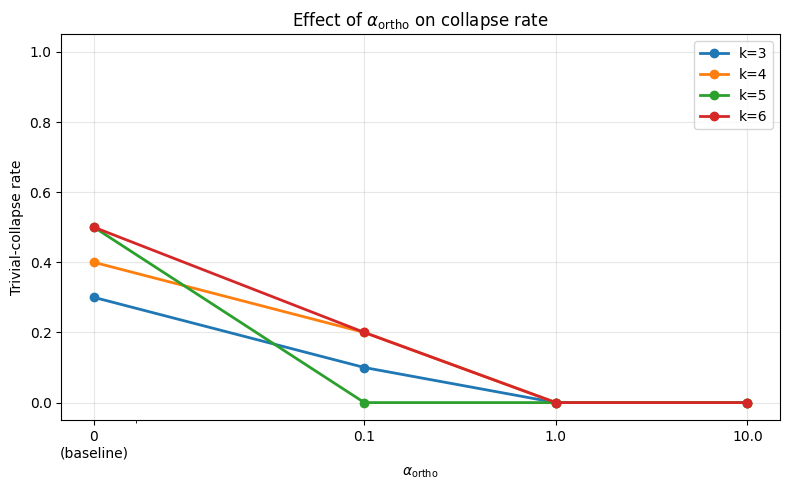

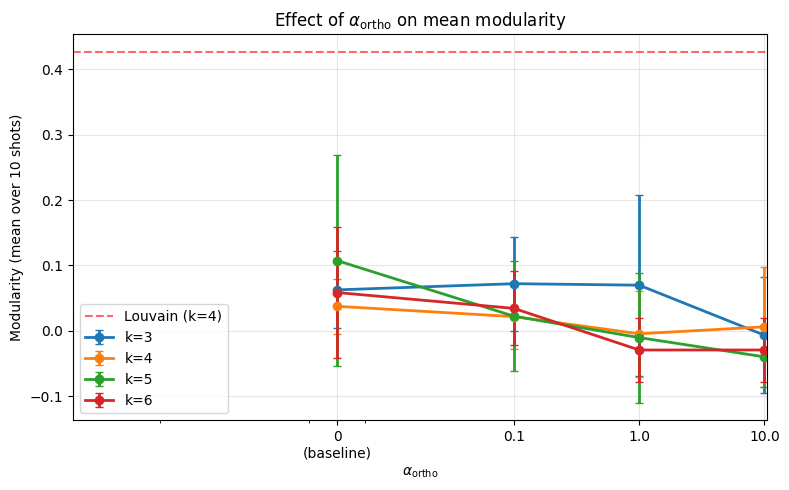

In [6]:
# Figure 1: collapse_rate vs alpha (lines per k)
fig, ax = plt.subplots(figsize=(8, 5))
for k in KS:
    sub = summary[summary['k'] == k].sort_values('alpha')
    ax.plot(sub['alpha'], sub['collapse_rate'], 'o-', label=f'k={k}', lw=2)
ax.set_xscale('symlog', linthresh=0.05)
ax.set_xticks([0.0, 0.1, 1.0, 10.0])
ax.set_xticklabels(['0\n(baseline)', '0.1', '1.0', '10.0'])
ax.set_xlabel(r'$\alpha_{\rm ortho}$')
ax.set_ylabel('Trivial-collapse rate')
ax.set_title(r'Effect of $\alpha_{\rm ortho}$ on collapse rate')
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig1_collapse_vs_alpha.png'), dpi=130)
plt.show()

# Figure 2: mean modularity vs alpha (lines per k) with mean ± std
fig, ax = plt.subplots(figsize=(8, 5))
for k in KS:
    sub = summary[summary['k'] == k].sort_values('alpha')
    ax.errorbar(sub['alpha'], sub['mod_mean'], yerr=sub['mod_std'],
                fmt='o-', capsize=3, label=f'k={k}', lw=2)
ax.axhline(louv_mod, color='red', ls='--', alpha=0.6,
           label=f'Louvain (k={len(louv_comms)})')
ax.set_xscale('symlog', linthresh=0.05)
ax.set_xticks([0.0, 0.1, 1.0, 10.0])
ax.set_xticklabels(['0\n(baseline)', '0.1', '1.0', '10.0'])
ax.set_xlabel(r'$\alpha_{\rm ortho}$')
ax.set_ylabel('Modularity (mean over 10 shots)')
ax.set_title(r'Effect of $\alpha_{\rm ortho}$ on mean modularity')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig2_modularity_vs_alpha.png'), dpi=130)
plt.show()

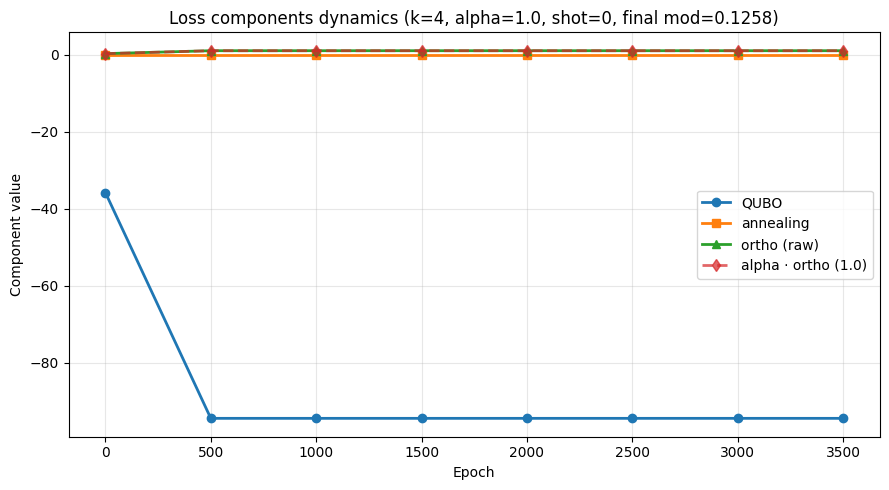

In [7]:
# Figure 3: loss-component dynamics for one good run.
# Pick k=4, alpha=1.0; among its 10 shots take the one with highest modularity.
target_k, target_alpha = 4, 1.0
sub = df[(df['k'] == target_k) & (df['alpha'] == target_alpha)]
if len(sub) > 0:
    best_idx = int(sub['modularity'].idxmax())
    best_shot_in_combo = int(df.loc[best_idx, 'shot'])
    history = component_traces[(target_k, target_alpha)][best_shot_in_combo]
    epochs_arr = [h['epoch'] for h in history]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(epochs_arr, [h['qubo'] for h in history], 'o-', label='QUBO', lw=2)
    ax.plot(epochs_arr, [h['annealing'] for h in history], 's-', label='annealing', lw=2)
    ax.plot(epochs_arr, [h['ortho'] for h in history], '^-', label='ortho (raw)', lw=2)
    ax.plot(epochs_arr, [target_alpha * h['ortho'] for h in history], 'd--',
            label=f'alpha · ortho ({target_alpha:.1f})', lw=2, alpha=0.7)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Component value')
    ax.set_title(f'Loss components dynamics (k={target_k}, alpha={target_alpha}, '
                 f'shot={best_shot_in_combo}, '
                 f'final mod={df.loc[best_idx, "modularity"]:.4f})')
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'fig3_loss_components.png'), dpi=130)
    plt.show()
else:
    print('No data for chosen (k, alpha)')

/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_19698/3339004055.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_alpha, labels=[str(a) for a in ALPHAS],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_19698/3339004055.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_alpha, labels=[str(a) for a in ALPHAS],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq/T/ipykernel_19698/3339004055.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_alpha, labels=[str(a) for a in ALPHAS],
/var/folders/x8/53bk6ftn2kn9qk2gkd725brh0000gq

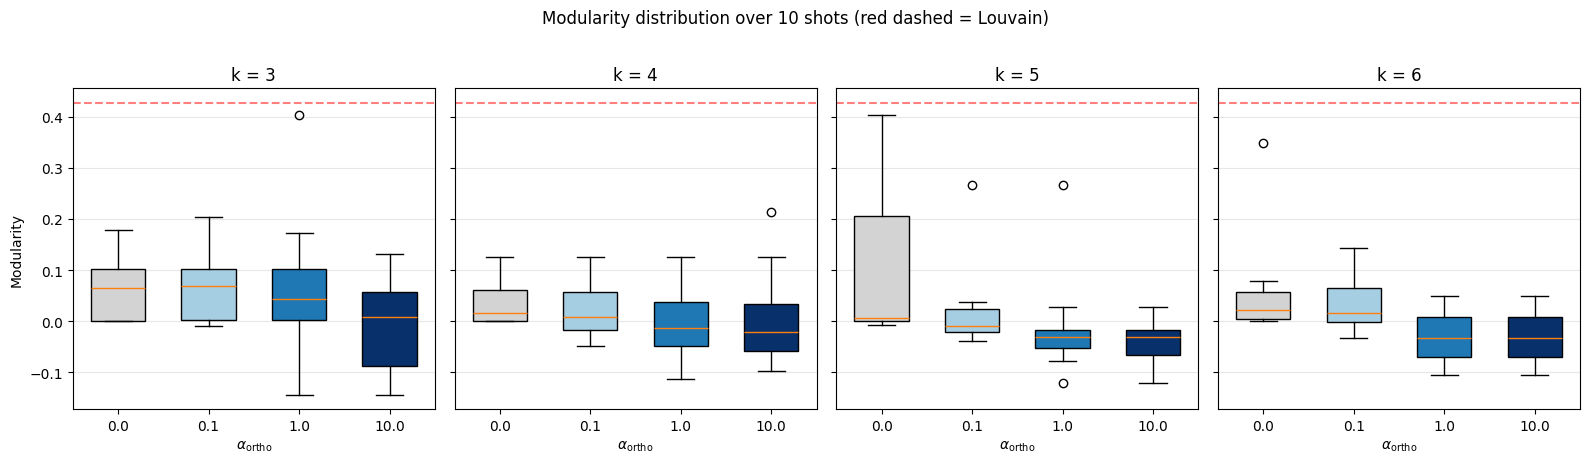

In [8]:
# Figure 4: boxplot of modularity across 10 shots, one subplot per k.
fig, axes = plt.subplots(1, len(KS), figsize=(4 * len(KS), 4.5), sharey=True)
for ax, k in zip(axes, KS):
    data_per_alpha = []
    for alpha in ALPHAS:
        sub = df[(df['k'] == k) & (df['alpha'] == alpha)]
        data_per_alpha.append(sub['modularity'].values)
    bp = ax.boxplot(data_per_alpha, labels=[str(a) for a in ALPHAS],
                    patch_artist=True, widths=0.6)
    for patch, c in zip(bp['boxes'], ['lightgray', '#a6cee3', '#1f78b4', '#08306b']):
        patch.set_facecolor(c)
    ax.axhline(louv_mod, color='red', ls='--', alpha=0.5)
    ax.set_xlabel(r'$\alpha_{\rm ortho}$')
    ax.set_title(f'k = {k}')
    ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('Modularity')
fig.suptitle('Modularity distribution over 10 shots (red dashed = Louvain)', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_modularity_boxplots.png'), dpi=130, bbox_inches='tight')
plt.show()

# Step 4 — Выводы

Заполняется содержательно после прогона. Шаблон ответа на вопросы из ТЗ:

1. **Помогает ли ortho-regularization, при каких α?** — смотрим на Fig.1
   (collapse rate vs α) и Fig.2 (mean modularity vs α). Ожидаемый паттерн:
   при умеренном $\alpha\sim 1$ collapse-rate падает, mean modularity растёт.

2. **Существует ли «сладкая» зона α?** — слишком малое $\alpha$ → ortho-сигнал
   тонет в шуме QUBO; слишком большое → штраф доминирует и оптимизация
   идёт за «равные размеры сообществ» вместо модулярности. По Fig.4 видно
   распределение по shots — оптимум там, где медиана высокая И разброс малый.

3. **Какое $k$ работает лучше?** — по `mod_best` и `mod_mean` для лучшего α.

4. **Уменьшилась ли дисперсия?** — сравнение `mod_std` для $\alpha=0$ vs
   лучший $\alpha$ в summary-таблице.

См. ячейку с автоматическим вердиктом ниже.

In [9]:
print('=' * 76)
print('AUTOMATIC VERDICT')
print('=' * 76)

baseline = summary[summary['alpha'] == 0.0].set_index('k')
best_lines = []
for k in KS:
    sub = summary[summary['k'] == k]
    base_row = sub[sub['alpha'] == 0.0].iloc[0]
    best_alpha_row = sub.loc[sub['mod_mean'].idxmax()]
    best_lines.append({
        'k': k,
        'baseline_mod_mean': base_row['mod_mean'],
        'baseline_collapse': base_row['collapse_rate'],
        'best_alpha': best_alpha_row['alpha'],
        'best_mod_mean': best_alpha_row['mod_mean'],
        'best_collapse': best_alpha_row['collapse_rate'],
        'mod_delta': best_alpha_row['mod_mean'] - base_row['mod_mean'],
        'collapse_delta': best_alpha_row['collapse_rate'] - base_row['collapse_rate'],
    })

verdict = pd.DataFrame(best_lines)
print(verdict.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Pick global best
global_best_idx = summary['mod_mean'].idxmax()
gb = summary.loc[global_best_idx]
print(f"\nGlobal best (by mean modularity over 10 shots): "
      f"k={int(gb['k'])}, alpha={gb['alpha']:.2f}, "
      f"mod_mean={gb['mod_mean']:.4f} ± {gb['mod_std']:.4f}, "
      f"collapse_rate={gb['collapse_rate']:.2f}, mean_used={gb['mean_used']:.1f}")

print("\n=== summary across alphas (positive = ortho helped) ===")
for line in best_lines:
    helped_mod = line['mod_delta'] > 0.005
    helped_col = line['collapse_delta'] < -0.05
    flag = '++' if (helped_mod and helped_col) else ('+' if helped_mod or helped_col else '~')
    print(f"  k={line['k']}: best alpha={line['best_alpha']:.1f}, "
          f"Δmod_mean={line['mod_delta']:+.4f}, "
          f"Δcollapse={line['collapse_delta']:+.2f}  [{flag}]")

AUTOMATIC VERDICT
 k  baseline_mod_mean  baseline_collapse  best_alpha  best_mod_mean  best_collapse  mod_delta  collapse_delta
 3             0.0626             0.3000      0.1000         0.0721         0.1000     0.0095         -0.2000
 4             0.0375             0.4000      0.0000         0.0375         0.4000     0.0000          0.0000
 5             0.1073             0.5000      0.0000         0.1073         0.5000     0.0000          0.0000
 6             0.0585             0.5000      0.0000         0.0585         0.5000     0.0000          0.0000

Global best (by mean modularity over 10 shots): k=5, alpha=0.00, mod_mean=0.1073 ± 0.1611, collapse_rate=0.50, mean_used=2.3

=== summary across alphas (positive = ortho helped) ===
  k=3: best alpha=0.1, Δmod_mean=+0.0095, Δcollapse=-0.20  [++]
  k=4: best alpha=0.0, Δmod_mean=+0.0000, Δcollapse=+0.00  [~]
  k=5: best alpha=0.0, Δmod_mean=+0.0000, Δcollapse=+0.00  [~]
  k=6: best alpha=0.0, Δmod_mean=+0.0000, Δcollapse=+0.00  